In [8]:
import torch
import numpy as np

def average_cosine(vectors):

    # Normalize each vector
    vectors_norm = vectors / vectors.norm(dim=1, keepdim=True)

    # Compute the cosine similarity matrix (dot product of normalized vectors)
    cosine_similarities = vectors_norm @ vectors_norm.T

    # Extract the upper triangle of the matrix, excluding the diagonal
    num_objects = vectors.shape[0]
    i, j = torch.triu_indices(num_objects, num_objects, offset=1)
    cosine_similarities_upper = cosine_similarities[i, j]
    # Calculate the average cosine similarity
    average_cosine = cosine_similarities_upper.mean().item()

    
    return average_cosine


def gen_W(num_objects, dim, target_cosine):
    # Define ranges
    sparsity_range = (0.002, 0.01)
    # Initialize the vectors tensor with random sparsity
    vectors = torch.zeros((num_objects, dim), dtype=torch.float)
    num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
    for i in range(num_objects):
        ones_indices = torch.randperm(dim)[:num_ones[i]]
        vectors[i, ones_indices] = 1

    cos = average_cosine(vectors)
    if target_cosine==0 and cos!=0:
        vectors = torch.zeros((num_objects, dim), dtype=torch.float)
        num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
        for i in range(num_objects):
            ones_indices = torch.randperm(dim)[:num_ones[i]]
            vectors[i, ones_indices] = 1

        cos = average_cosine(vectors)
        

    while(cos<target_cosine):
        # Randomly pick a pair of objects i and j
        indices = torch.randperm(num_objects)[:2]
        i, j = indices[0], indices[1]
        vi = vectors[i, :]
        vj = vectors[j, :]

        # Identify dimensions where only one of them has a 1 using XOR
        diff_indices = torch.nonzero(vi.int() ^ vj.int()).flatten()
        if len(diff_indices) > 0:
            # Randomly pick one such dimension
            dim_to_change = diff_indices[torch.randint(len(diff_indices), (1,)).item()]
        else:
            continue

        # Determine which vector has 0 at the chosen dimension
        if vi[dim_to_change] == 0:
            index_to_modify = i
        else:
            index_to_modify = j

        # Set the value of this object at the chosen dimension to 1
        vectors[index_to_modify, dim_to_change] = 1

        # Find a dimension in the same object that currently equals 1
        ones_indices = torch.nonzero(vectors[index_to_modify] == 1).flatten()
        ones_indices = ones_indices[ones_indices != dim_to_change]  # Exclude the modified dimension

        # Randomly pick one such dimension to set to 0
        dim_to_zero = ones_indices[torch.randint(len(ones_indices), (1,)).item()]
        vectors[index_to_modify, dim_to_zero] = 0

        # Compute the average cosine again
        cos = average_cosine(vectors)
#     print(cos)
    return vectors.T



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import torch
import numpy as np
from tqdm.notebook import tqdm

# Set parameters
num_objects = 10
input_dim = num_objects
hidden_dim = 10000
output_dim = 1

# Ground truth ranking
ground_truth_ranking = list(range(num_objects))

# Create all possible pairs and labels
test_pairs = [(i, j) for i in range(num_objects) for j in range(num_objects) if ((i != j) and (i-j!=1) and (j-i!=1))]
test_labels = [1 if ground_truth_ranking.index(i) < ground_truth_ranking.index(j) else -1 for i, j in test_pairs]

# train_pairs = [(i, i+1) for i in range(num_objects-1)]
# train_labels = [1 for i, j in train_pairs]

train_pairs = [(i, j) for i in range(num_objects) for j in range(num_objects) if (i != j)]
train_labels = [1 if ground_truth_ranking.index(i) < ground_truth_ranking.index(j) else -1 for i, j in train_pairs]

# One-hot encode the input
one_hot_vectors = torch.eye(num_objects)

# Split into training and testing datasets


# Initialize results storage
all_accuracies = []
all_accuracies2 = []
all_accuracies_w = []
all_accuracies_w2 = []
all_mean_values = []
# Repeat the experiment
for repeat in tqdm(range(100), desc="Repeats"):
    print(repeat)
    # Initialize weights for both cases
    W1 = gen_W(num_objects, hidden_dim, 0)
    W2 = gen_W(num_objects, hidden_dim, 0.1)
    P1 = torch.randn(output_dim, hidden_dim) * 0.0001
    P2 = torch.randn(output_dim, hidden_dim) * 0.0001
    allcorrect1 = False
    allcorrect2 = False
    # Learning rate
    eta = 0.01

    # Training parameters
    total_iterations = 400

    accuracies1 = []
    accuracies2 = []
    
    accuracies_w1 = []
    accuracies_w2 = []
    
    mean_v_values = np.zeros((total_iterations, num_objects))
    mean_v_values2 = np.zeros((total_iterations, num_objects))

    # Training loop
    for iteration in range(total_iterations):
        # Randomly pick a sample from the training set
        idx = np.random.randint(0, len(train_pairs))
        (i, j), label = train_pairs[idx], train_labels[idx]

        # Case 1: Training with W1
        s_i1 = W1 @ one_hot_vectors[i]
        s_j1 = W1 @ one_hot_vectors[j]
        v_i1 = P1 @ s_i1
        v_j1 = P1 @ s_j1

        error1 = torch.sign(torch.maximum((label * (v_i1 - v_j1) +1), torch.tensor(0))*label)

#         break
        e_vec1 = error1 
#         print(e_vec1)

        with torch.no_grad():
            if not allcorrect1:
                P1 += eta * torch.outer(e_vec1, s_j1 - s_i1)

        # Case 2: Training with W2
        s_i2 = W2 @ one_hot_vectors[i]
        s_j2 = W2 @ one_hot_vectors[j]
        v_i2 = P2 @ s_i2
        v_j2 = P2 @ s_j2

        error2 = torch.sign(torch.maximum((label * (v_i2 - v_j2) +1), torch.tensor(0))*label)
        e_vec2 = error2

        with torch.no_grad():
            if not allcorrect2:
                P2 += eta * torch.outer(e_vec2, s_j2 - s_i2)
        for i in range(num_objects):
            s1 = W1 @ one_hot_vectors[i]
            v1 = P1 @ s1
            s2 = W2 @ one_hot_vectors[i]
            v2 = P2 @ s2
            mean_v_values[iteration, i] = v1.mean().item()
            mean_v_values2[iteration, i] = v2.mean().item()
            
        summed_v_values = mean_v_values[iteration, :]
        learned_ranking = sorted(range(num_objects), key=lambda i: summed_v_values[i])
        if learned_ranking == list(ground_truth_ranking):
            if allcorrect1 == False:
                print('ortho:', iteration, len(accuracies_w1))
            allcorrect1 = True
            
            
            
        summed_v_values2 = mean_v_values2[iteration, :]
        learned_ranking2 = sorted(range(num_objects), key=lambda i: summed_v_values2[i])
        if learned_ranking2 == list(ground_truth_ranking):
            if allcorrect2 == False:
                print('0.1:', iteration, len(accuracies_w2))
            allcorrect2 = True
            
            

        # Evaluate on the test set
        if iteration % 1 == 0:  # Test every iteration
            correct1 = 0
            correct2 = 0

            for (i_test, j_test), label_test in zip(test_pairs, test_labels):
                # Case 1: Testing with W1
                s_i_test1 = W1 @ one_hot_vectors[i_test]
                s_j_test1 = W1 @ one_hot_vectors[j_test]
                v_i_test1 = P1 @ s_i_test1
                v_j_test1 = P1 @ s_j_test1
                prediction1 = 1 if v_i_test1.mean() < v_j_test1.mean() else -1
                correct1 += (prediction1 == label_test)

                # Case 2: Testing with W2
                s_i_test2 = W2 @ one_hot_vectors[i_test]
                s_j_test2 = W2 @ one_hot_vectors[j_test]
                v_i_test2 = P2 @ s_i_test2
                v_j_test2 = P2 @ s_j_test2
                prediction2 = 1 if v_i_test2.mean() < v_j_test2.mean() else -1
                correct2 += (prediction2 == label_test)

            # Calculate accuracies
            accuracy1 = correct1 / len(test_pairs)
            accuracy2 = correct2 / len(test_pairs)
            accuracies1.append(accuracy1)
            accuracies2.append(accuracy2)
            if error1 != 0:
                accuracies_w1.append(accuracy1)
            if error2 != 0:
                accuracies_w2.append(accuracy2)
                
    all_mean_values.append(mean_v_values[-1,:])
    all_accuracies.append(accuracies1)
    all_accuracies2.append(accuracies2)
    accuracies_w1_complete = np.ones(total_iterations)
    accuracies_w2_complete = np.ones(total_iterations)
    accuracies_w1_complete[:len(accuracies_w1)] = np.array(accuracies_w1)
    accuracies_w2_complete[:len(accuracies_w2)] = np.array(accuracies_w2)
    all_accuracies_w.append(accuracies_w1_complete)
    all_accuracies_w2.append(accuracies_w2_complete)



Repeats:   0%|          | 0/100 [00:00<?, ?it/s]

0
ortho: 46 22
0.1: 70 41
1
0.1: 144 34
ortho: 205 54
2
ortho: 76 35
0.1: 140 53
3
0.1: 111 37
ortho: 123 38
4
0.1: 135 39
ortho: 257 60
5
ortho: 30 18
0.1: 147 45
6
ortho: 195 65
0.1: 195 47
7
ortho: 147 38
0.1: 338 76
8
ortho: 44 20
0.1: 199 54
9
0.1: 125 40
ortho: 172 50
10
0.1: 169 57
ortho: 211 59
11
ortho: 210 59
0.1: 210 55
12
ortho: 189 62
0.1: 326 76
13
0.1: 146 58
ortho: 171 50
14
0.1: 103 41
ortho: 144 46
15
ortho: 111 41
0.1: 243 78
16
ortho: 143 50
0.1: 143 42
17
0.1: 78 35
ortho: 180 49
18
ortho: 70 33
0.1: 147 42
19
0.1: 164 53
ortho: 313 82
20
ortho: 112 45
0.1: 220 64
21
0.1: 326 62
22
0.1: 80 35
ortho: 275 58
23
0.1: 83 36
ortho: 213 50
24
0.1: 204 68
ortho: 209 68
25
0.1: 104 35
ortho: 255 63
26
ortho: 128 34
0.1: 130 41
27
ortho: 132 50
0.1: 245 62
28
0.1: 252 64
ortho: 284 78
29
0.1: 241 48
ortho: 296 75
30
0.1: 135 43
ortho: 296 82
31
ortho: 105 35
0.1: 136 42
32
ortho: 97 46
0.1: 240 69
33
ortho: 69 29
0.1: 243 55
34
ortho: 123 34
0.1: 245 65
35
ortho: 233 55
0.1

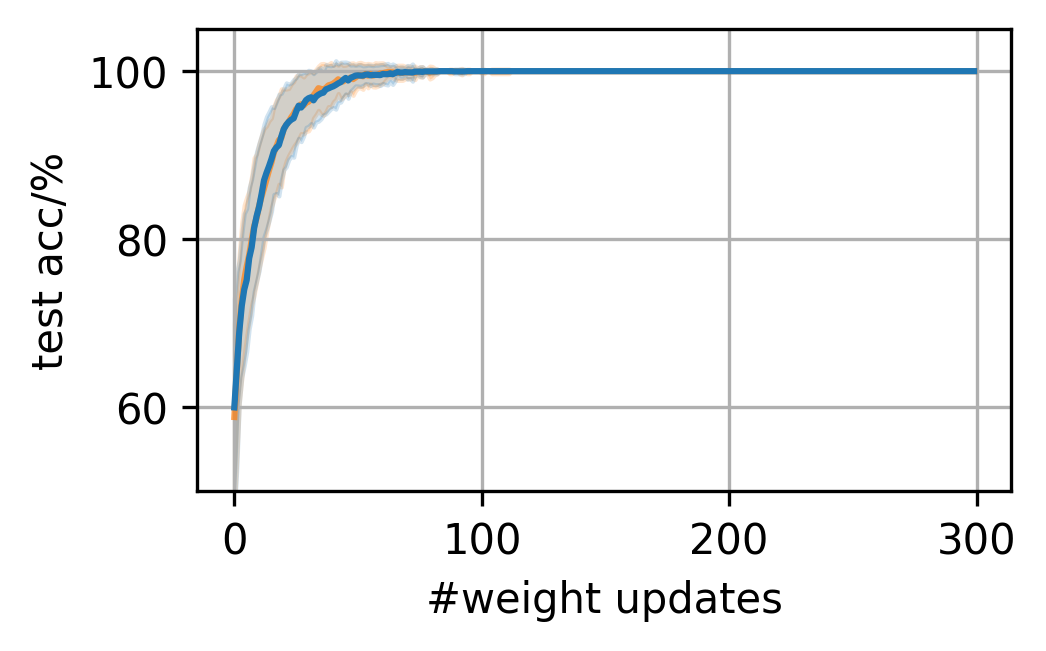

In [12]:
import matplotlib.pyplot as plt
data_array = np.array(all_accuracies_w)[:,:300]*100

# Calculate mean and standard deviation across the data
mean_values = np.mean(data_array, axis=0)
std_values = np.std(data_array, axis=0)

# Create an array for the iteration indices
iterations = np.arange(data_array.shape[1])

# Plot mean with shaded standard deviation
plt.figure(figsize=(3.5, 2), dpi=300)

data_array2 = np.array(all_accuracies_w2)[:,:300]*100

# Calculate mean and standard deviation across the data
mean_values2 = np.mean(data_array2, axis=0)
std_values2 = np.std(data_array2, axis=0)



# Create an array for the iteration indices
iterations = np.arange(data_array2.shape[1])

# Plot mean with shaded standard deviation
plt.fill_between(iterations, mean_values2 - std_values2, mean_values2 + std_values2, color="tab:orange", alpha=0.2, label="Standard Deviation")
plt.plot(iterations, mean_values2, label="Mean Correlation", color="tab:orange", alpha=0.7)

plt.fill_between(iterations, mean_values - std_values, mean_values + std_values, color="tab:blue", alpha=0.2, label="Standard Deviation")
plt.plot(iterations, mean_values, label="Mean Correlation", color="tab:blue")

# epochs = iterations / 90
# plt.xticks(ticks=iterations[::90].tolist()+[450], labels=np.arange(6).astype(np.int8))
plt.ylim(50,105)
plt.xticks(np.arange(0,301,100))
# Add labels and title
# plt.title("Correlation Change Across Training Iterations")
plt.xlabel("#weight updates")
plt.ylabel("test acc/%")
# plt.legend()
plt.grid(True)

# Show the plot
plt.show()

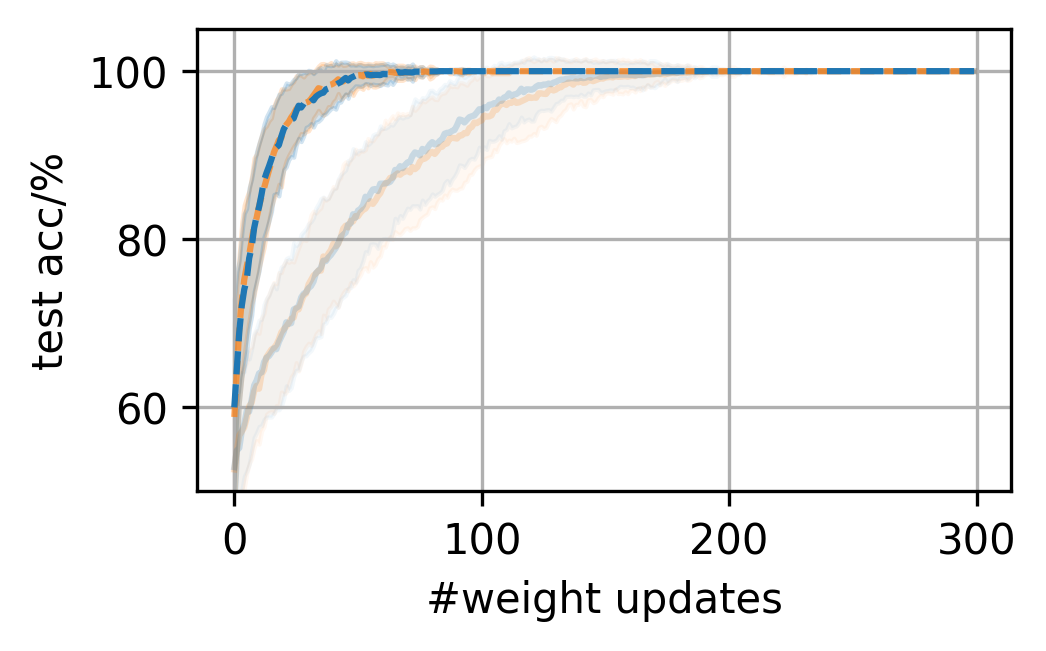

In [18]:
import matplotlib.pyplot as plt
import numpy as np
data_array = np.array(all_accuracies_w)[:,:300]*100

# Calculate mean and standard deviation across the data
mean_values = np.mean(data_array, axis=0)
std_values = np.std(data_array, axis=0)

# Create an array for the iteration indices
iterations = np.arange(data_array.shape[1])

# Plot mean with shaded standard deviation
plt.figure(figsize=(3.5, 2), dpi=300)

data_array2 = np.array(all_accuracies_w2)[:,:300]*100

# Calculate mean and standard deviation across the data
mean_values2 = np.mean(data_array2, axis=0)
std_values2 = np.std(data_array2, axis=0)

mean_values_adj = np.load('mean_values_adj_ort.npy')
std_values_adj = np.load('std_values_adj_ort.npy')
mean_values2_adj = np.load('mean_values_adj_0_1.npy')
std_values2_adj = np.load('std_values_adj_0_1.npy')

plt.fill_between(iterations, mean_values2_adj - std_values2_adj, mean_values2_adj + std_values2_adj,
                 color="tab:orange", alpha=0.05, label="Standard Deviation")
plt.plot(iterations, mean_values2_adj,'-', label="Mean Correlation", color="tab:orange", alpha=0.2)

plt.fill_between(iterations, mean_values_adj - std_values_adj, mean_values_adj + std_values_adj,
                 color="tab:blue", alpha=0.05, label="Standard Deviation")
plt.plot(iterations, mean_values_adj, '-', label="Mean Correlation", color="tab:blue", alpha=0.2)


# Create an array for the iteration indices
iterations = np.arange(data_array2.shape[1])

# Plot mean with shaded standard deviation
plt.fill_between(iterations, mean_values2 - std_values2, mean_values2 + std_values2, color="tab:orange", alpha=0.2, label="Standard Deviation")
plt.plot(iterations, mean_values2,'--', label="Mean Correlation", color="tab:orange", alpha=0.7)

plt.fill_between(iterations, mean_values - std_values, mean_values + std_values, color="tab:blue", alpha=0.2, label="Standard Deviation")
plt.plot(iterations, mean_values, '--', label="Mean Correlation", color="tab:blue")



# epochs = iterations / 90
# plt.xticks(ticks=iterations[::90].tolist()+[450], labels=np.arange(6).astype(np.int8))
plt.ylim(50,105)
plt.xticks(np.arange(0,301,100))
# Add labels and title
# plt.title("Correlation Change Across Training Iterations")
plt.xlabel("#weight updates")
plt.ylabel("test acc/%")
# plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [5]:
np.save('mean_values_rand_ort',mean_values)
np.save('std_values_rand_ort',std_values)
np.save('mean_values_rand_0_1',mean_values2)
np.save('std_values_rand_0_1',std_values2)

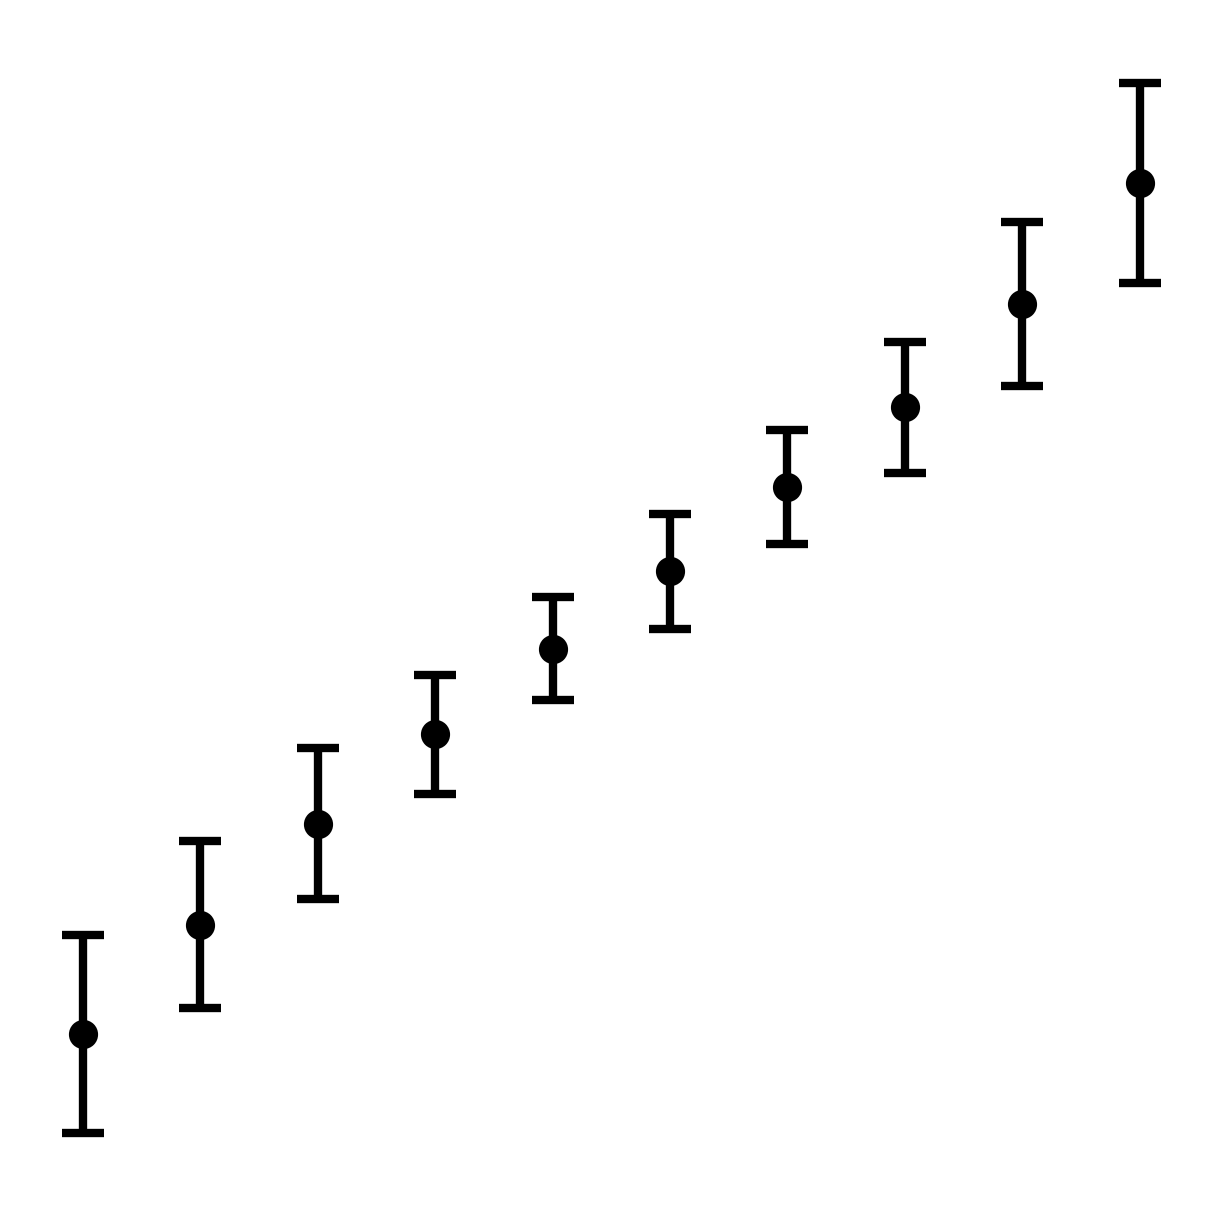

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Example data

# Calculate mean and standard deviation across the samples
mean_values = np.array(all_mean_values).mean(axis=0)
std_values = np.array(all_mean_values).std(axis=0)

plt.figure(figsize=(5, 5), dpi=300)

# Plot the scatter points with error bars
plt.errorbar(
    range(10),              # x-values
    mean_values,            # y-values (means)
    yerr=std_values,        # error values (e.g., standard deviation)
    fmt='.',                # marker style (using 'x')
    color='black',          # color of markers and error bars
    capsize=5,              # size of the error bar caps
    markersize=10,          # size of the marker
    elinewidth=2,           # width of the error bar lines
    markeredgewidth=2       # width of the marker edges
)

# Optionally, plot a reference line (as in your code)
# plt.plot(range(10), np.arange(10) - 4.25, '--', c='black', alpha=.6)

plt.axis('off')
plt.show()


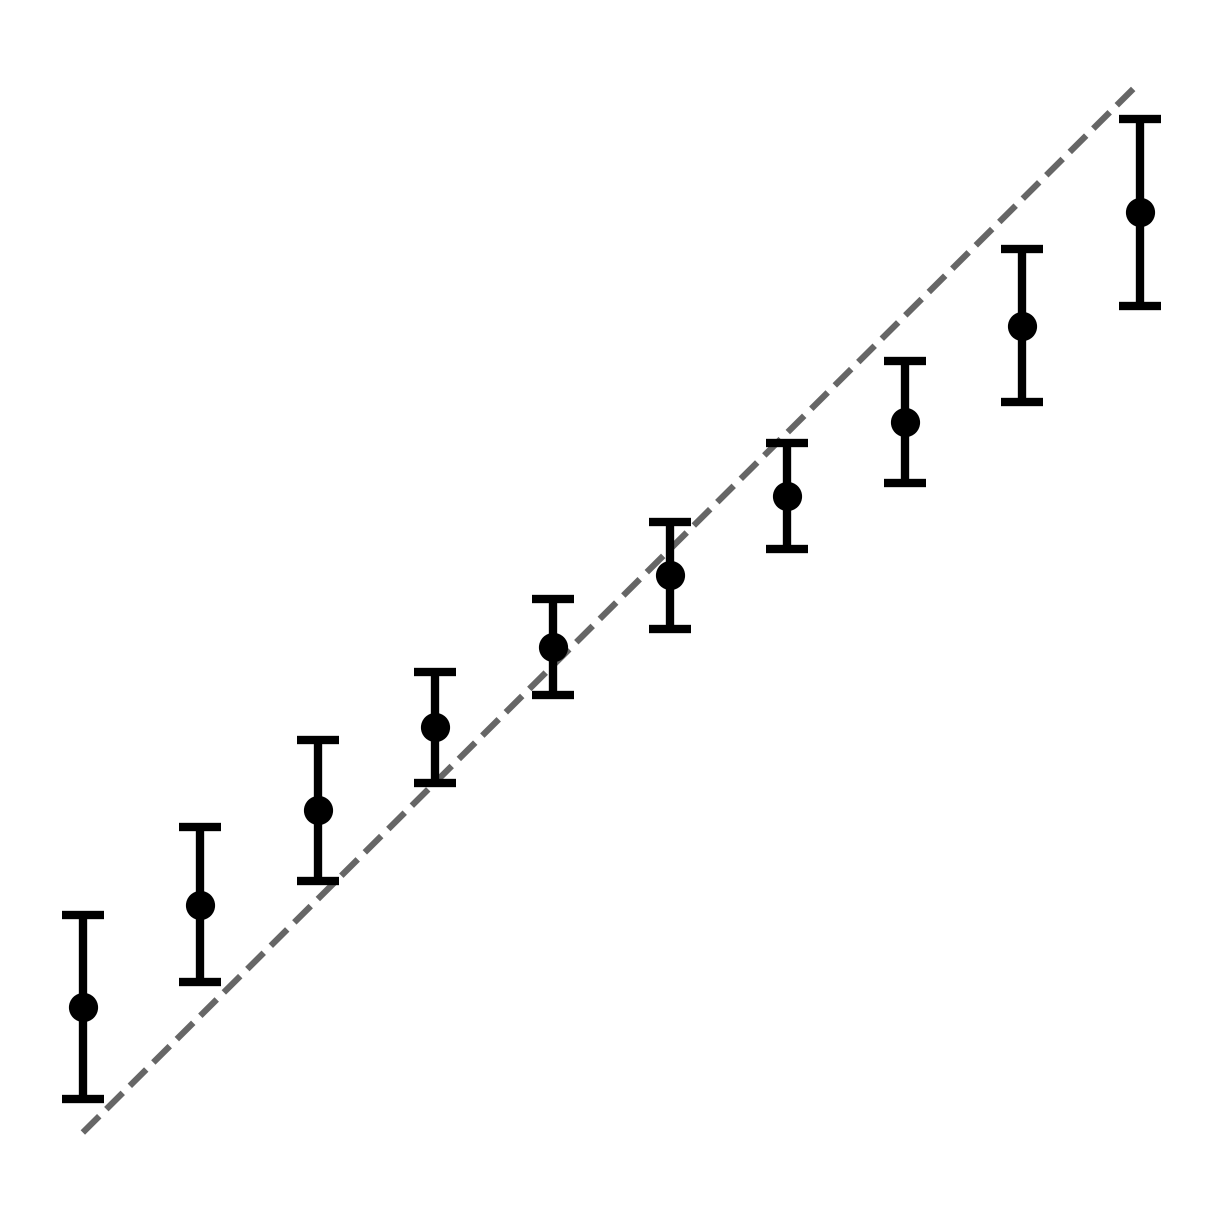

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Example data

# Calculate mean and standard deviation across the samples
mean_values = np.array(all_mean_values).mean(axis=0)
std_values = np.array(all_mean_values).std(axis=0)

plt.figure(figsize=(5, 5), dpi=300)

# Plot the scatter points with error bars
plt.errorbar(
    range(10),              # x-values
    mean_values,            # y-values (means)
    yerr=std_values,        # error values (e.g., standard deviation)
    fmt='.',                # marker style (using 'x')
    color='black',          # color of markers and error bars
    capsize=5,              # size of the error bar caps
    markersize=10,          # size of the marker
    elinewidth=2,           # width of the error bar lines
    markeredgewidth=2       # width of the marker edges
)
# plt.plot(range(10),mean_values)
# Optionally, plot a reference line (as in your code)
plt.plot(range(10), np.arange(10) - 4.5, '--', c='black', alpha=.6)

plt.axis('off')
plt.show()
